# Chapter 83 - Dropout

Earlier TinyGPT models included dropout layers without examining their behavior directly.

This chapter isolates dropout, places it on Transformer branch outputs and attention weights, and compares otherwise identical models trained with rates `0.0` and `0.1`.

## Learning goals

By the end of this chapter, you will be able to:

- explain dropout and inverted scaling;

- distinguish training mode from evaluation mode;

- place dropout on embeddings, attention weights, and residual branch outputs;

- compare train-split and held-out loss with and without dropout;

- explain why dropout can raise training loss without guaranteeing better validation loss;

- disable dropout during validation and generation; and

- debug inconsistent evaluation on a fixed batch.

## Terms

An **activation** is an intermediate floating-point value produced inside a neural network.

**Regularization** changes training to discourage fitting the training examples too narrowly.

The **dropout rate** is the probability of replacing an activation with zero during training.

A **residual branch** transforms the main stream before its output is added back to that stream.

**Overfitting** occurs when training performance keeps improving while performance on held-out data stops improving or becomes worse.

## What dropout does

During training, dropout independently zeros selected activations and scales the survivors by `1 / (1 - dropout_rate)`.

This inverted scaling keeps each activation's expected value unchanged when the input is fixed.

During evaluation, dropout returns its input unchanged.

In [1]:
import torch  # noqa: I001


device = "cpu"
activation_values = torch.tensor(
    [[1.0, 2.0, 3.0, 4.0], [5.0, 6.0, 7.0, 8.0]],
    dtype=torch.float32,
)
dropout_layer = torch.nn.Dropout(p=0.5)

dropout_layer.train()
torch.manual_seed(83)
training_output = dropout_layer(activation_values)

dropout_layer.eval()
evaluation_output = dropout_layer(activation_values)

print("Device:", device)
print("Input:")
print(activation_values)
print("Training output with p=0.5:")
print(training_output)
print("Evaluation output:")
print(evaluation_output)

assert torch.equal(evaluation_output, activation_values)
assert torch.count_nonzero(training_output == 0) > 0

Device: cpu
Input:
tensor([[1., 2., 3., 4.],
        [5., 6., 7., 8.]])
Training output with p=0.5:
tensor([[ 0.,  4.,  6.,  0.],
        [10., 12., 14.,  0.]])
Evaluation output:
tensor([[1., 2., 3., 4.],
        [5., 6., 7., 8.]])


With `p=0.5`, surviving values are doubled rather than left at their original magnitude.

One mask does not preserve the mean exactly, but the average over many masks approaches the original activation values.

In [2]:
dropout_layer.train()
torch.manual_seed(8300)
repeated_outputs = torch.stack([dropout_layer(activation_values) for _ in range(2000)])
mean_training_output = repeated_outputs.mean(dim=0)

print("Mean over 2,000 training-mode masks:")
print(mean_training_output)
print("Maximum absolute difference from input:")
print(float((mean_training_output - activation_values).abs().max()))

assert torch.allclose(mean_training_output, activation_values, atol=0.25)

Mean over 2,000 training-mode masks:
tensor([[1.0230, 1.9780, 2.9100, 4.0760],
        [5.1350, 6.0180, 6.8880, 8.1600]])
Maximum absolute difference from input:
0.15999984741210938


## Training and evaluation modes

`model.train()` recursively enables training behavior for dropout and any other mode-sensitive modules.

`model.eval()` recursively disables dropout but does not disable gradient tracking by itself.

Use `model.eval()` together with `torch.no_grad()` during ordinary validation and generation.

In [3]:
dropout_layer.train()
torch.manual_seed(1)
first_training_output = dropout_layer(activation_values)
torch.manual_seed(2)
second_training_output = dropout_layer(activation_values)

dropout_layer.eval()
torch.manual_seed(1)
first_evaluation_output = dropout_layer(activation_values)
torch.manual_seed(2)
second_evaluation_output = dropout_layer(activation_values)

print(
    "Training outputs equal:",
    torch.equal(
        first_training_output,
        second_training_output,
    ),
)
print(
    "Evaluation outputs equal:",
    torch.equal(
        first_evaluation_output,
        second_evaluation_output,
    ),
)

assert not torch.equal(first_training_output, second_training_output)
assert torch.equal(first_evaluation_output, second_evaluation_output)

Training outputs equal: False
Evaluation outputs equal: True


The changed seeds affect only training-mode output because evaluation-mode dropout is the identity function.

## Standard dropout locations in TinyGPT

This implementation uses dropout in four places:

- after token and position embeddings are added;

- on normalized attention weights;

- after the attention output projection; and

- after the feedforward output projection.

The last two placements regularize transformed branches before residual addition, while the main residual stream remains intact.

Attention-weight dropout can make a realized row stop summing to one because some probabilities are zeroed and the survivors are scaled.

The row remains correctly scaled in expectation, and evaluation mode restores the original softmax weights.

## Define dropout-aware attention

The attention module applies one dropout layer to attention weights and another to the projected branch output.

In [4]:
import math  # noqa: I001


class MultiHeadCausalSelfAttention(torch.nn.Module):
    embedding_dimension: int
    number_of_attention_heads: int
    head_size: int

    def __init__(
        self,
        embedding_dimension: int,
        number_of_attention_heads: int,
        context_length: int,
        dropout_rate: float,
    ) -> None:
        super().__init__()
        if embedding_dimension % number_of_attention_heads != 0:
            raise ValueError("Attention heads must divide the embedding dimension.")
        if not 0.0 <= dropout_rate < 1.0:
            raise ValueError("dropout_rate must be in [0, 1).")

        self.embedding_dimension = embedding_dimension
        self.number_of_attention_heads = number_of_attention_heads
        self.head_size = embedding_dimension // number_of_attention_heads
        self.query_projection = torch.nn.Linear(
            embedding_dimension,
            embedding_dimension,
            bias=False,
        )
        self.key_projection = torch.nn.Linear(
            embedding_dimension,
            embedding_dimension,
            bias=False,
        )
        self.value_projection = torch.nn.Linear(
            embedding_dimension,
            embedding_dimension,
            bias=False,
        )
        self.output_projection = torch.nn.Linear(
            embedding_dimension,
            embedding_dimension,
        )
        self.attention_dropout = torch.nn.Dropout(dropout_rate)
        self.output_dropout = torch.nn.Dropout(dropout_rate)
        self.register_buffer(
            "causal_mask",
            torch.tril(torch.ones(context_length, context_length, dtype=torch.bool)),
        )

    def forward(self, input_values: torch.Tensor) -> torch.Tensor:
        batch_size, sequence_length, _ = input_values.shape

        def split_heads(values: torch.Tensor) -> torch.Tensor:
            return values.view(
                batch_size,
                sequence_length,
                self.number_of_attention_heads,
                self.head_size,
            ).transpose(1, 2)

        queries = split_heads(self.query_projection(input_values))
        keys = split_heads(self.key_projection(input_values))
        values = split_heads(self.value_projection(input_values))
        attention_scores = queries @ keys.transpose(-2, -1)
        attention_scores = attention_scores / math.sqrt(self.head_size)
        causal_mask = self.causal_mask[:sequence_length, :sequence_length]
        attention_scores = attention_scores.masked_fill(
            ~causal_mask,
            float("-inf"),
        )
        attention_weights = torch.softmax(attention_scores, dim=-1)
        dropped_attention_weights = self.attention_dropout(attention_weights)
        attended_values = dropped_attention_weights @ values
        concatenated_values = (
            attended_values.transpose(1, 2)
            .contiguous()
            .view(
                batch_size,
                sequence_length,
                self.embedding_dimension,
            )
        )
        projected_values = self.output_projection(concatenated_values)
        output_values: torch.Tensor = self.output_dropout(projected_values)
        return output_values

## Define feedforward and residual branches

The feedforward dropout is the last operation in that transformed branch.

Each branch output is added to an undropped residual stream.

In [5]:
class FeedForwardNetwork(torch.nn.Module):
    def __init__(self, embedding_dimension: int, dropout_rate: float) -> None:
        super().__init__()
        self.network = torch.nn.Sequential(
            torch.nn.Linear(embedding_dimension, 4 * embedding_dimension),
            torch.nn.ReLU(),
            torch.nn.Linear(4 * embedding_dimension, embedding_dimension),
            torch.nn.Dropout(dropout_rate),
        )

    def forward(self, input_values: torch.Tensor) -> torch.Tensor:
        output_values: torch.Tensor = self.network(input_values)
        return output_values


class TransformerBlock(torch.nn.Module):
    def __init__(
        self,
        embedding_dimension: int,
        number_of_attention_heads: int,
        context_length: int,
        dropout_rate: float,
    ) -> None:
        super().__init__()
        self.attention_norm = torch.nn.LayerNorm(embedding_dimension)
        self.attention = MultiHeadCausalSelfAttention(
            embedding_dimension=embedding_dimension,
            number_of_attention_heads=number_of_attention_heads,
            context_length=context_length,
            dropout_rate=dropout_rate,
        )
        self.feedforward_norm = torch.nn.LayerNorm(embedding_dimension)
        self.feedforward = FeedForwardNetwork(
            embedding_dimension=embedding_dimension,
            dropout_rate=dropout_rate,
        )

    def forward(self, input_values: torch.Tensor) -> torch.Tensor:
        attention_branch = self.attention(self.attention_norm(input_values))
        values_after_attention = input_values + attention_branch
        feedforward_branch = self.feedforward(
            self.feedforward_norm(values_after_attention)
        )
        output_values: torch.Tensor = values_after_attention + feedforward_branch
        return output_values

## Define TinyGPT with embedding dropout

Setting `dropout_rate=0.0` preserves the same module structure while making every dropout layer an identity in both modes.

In [6]:
class TinyGPT(torch.nn.Module):
    vocabulary_size: int
    context_length: int
    dropout_rate: float

    def __init__(
        self,
        vocabulary_size: int,
        context_length: int,
        embedding_dimension: int,
        number_of_attention_heads: int,
        number_of_transformer_blocks: int,
        dropout_rate: float,
    ) -> None:
        super().__init__()
        if not 0.0 <= dropout_rate < 1.0:
            raise ValueError("dropout_rate must be in [0, 1).")
        self.vocabulary_size = vocabulary_size
        self.context_length = context_length
        self.dropout_rate = dropout_rate
        self.token_embedding = torch.nn.Embedding(
            vocabulary_size,
            embedding_dimension,
        )
        self.position_embedding = torch.nn.Embedding(
            context_length,
            embedding_dimension,
        )
        self.embedding_dropout = torch.nn.Dropout(dropout_rate)
        self.transformer_blocks = torch.nn.ModuleList(
            [
                TransformerBlock(
                    embedding_dimension=embedding_dimension,
                    number_of_attention_heads=number_of_attention_heads,
                    context_length=context_length,
                    dropout_rate=dropout_rate,
                )
                for _ in range(number_of_transformer_blocks)
            ]
        )
        self.final_norm = torch.nn.LayerNorm(embedding_dimension)
        self.output_layer = torch.nn.Linear(embedding_dimension, vocabulary_size)

    def forward(
        self,
        input_token_ids: torch.Tensor,
        target_token_ids: torch.Tensor | None = None,
    ) -> tuple[torch.Tensor, torch.Tensor | None]:
        if input_token_ids.ndim != 2:
            raise ValueError("Inputs must have shape [batch, time].")
        batch_size, sequence_length = input_token_ids.shape
        if sequence_length > self.context_length:
            raise ValueError("Input exceeds model context length.")

        position_ids = torch.arange(sequence_length, device=input_token_ids.device)
        hidden_values = self.token_embedding(input_token_ids)
        hidden_values = hidden_values + self.position_embedding(position_ids)
        hidden_values = self.embedding_dropout(hidden_values)
        for transformer_block in self.transformer_blocks:
            hidden_values = transformer_block(hidden_values)
        logits = self.output_layer(self.final_norm(hidden_values))

        loss = None
        if target_token_ids is not None:
            if target_token_ids.shape != input_token_ids.shape:
                raise ValueError("Targets must have the same shape as inputs.")
            loss = torch.nn.functional.cross_entropy(
                logits.reshape(batch_size * sequence_length, self.vocabulary_size),
                target_token_ids.reshape(batch_size * sequence_length),
            )
        return logits, loss

    @torch.no_grad()
    def generate(
        self,
        input_token_ids: torch.Tensor,
        number_of_new_tokens: int,
        generator: torch.Generator,
        temperature: float = 1.0,
        top_k: int | None = None,
    ) -> torch.Tensor:
        if temperature <= 0:
            raise ValueError("temperature must be positive.")
        generated_ids = input_token_ids
        for _ in range(number_of_new_tokens):
            model_input = generated_ids[:, -self.context_length :]
            logits, _ = self(model_input)
            next_logits = logits[:, -1, :] / temperature
            if top_k is not None:
                effective_top_k = min(top_k, self.vocabulary_size)
                top_values, _ = torch.topk(next_logits, effective_top_k)
                next_logits = next_logits.masked_fill(
                    next_logits < top_values[:, -1, None],
                    float("-inf"),
                )
            probabilities = torch.softmax(next_logits, dim=-1)
            next_ids = torch.multinomial(
                probabilities,
                num_samples=1,
                generator=generator,
            )
            generated_ids = torch.cat([generated_ids, next_ids], dim=1)
        return generated_ids

## Verify mode propagation through TinyGPT

Calling a mode method on the top-level model updates every nested dropout layer.

In [7]:
torch.manual_seed(83)
example_model = TinyGPT(
    vocabulary_size=50,
    context_length=8,
    embedding_dimension=16,
    number_of_attention_heads=4,
    number_of_transformer_blocks=1,
    dropout_rate=0.5,
)
example_input_ids = torch.randint(0, 50, (1, 8))
dropout_modules = [
    module for module in example_model.modules() if isinstance(module, torch.nn.Dropout)
]

example_model.train()
torch.manual_seed(1)
first_training_logits, _ = example_model(example_input_ids)
torch.manual_seed(2)
second_training_logits, _ = example_model(example_input_ids)

example_model.eval()
torch.manual_seed(1)
first_evaluation_logits, _ = example_model(example_input_ids)
torch.manual_seed(2)
second_evaluation_logits, _ = example_model(example_input_ids)

print("Dropout modules:", len(dropout_modules))
print("Top-level training flag after eval:", example_model.training)
print("Nested dropout flags:", [module.training for module in dropout_modules])
print(
    "Training logits equal:",
    torch.equal(
        first_training_logits,
        second_training_logits,
    ),
)
print(
    "Evaluation logits equal:",
    torch.equal(
        first_evaluation_logits,
        second_evaluation_logits,
    ),
)

assert not torch.equal(first_training_logits, second_training_logits)
assert torch.equal(first_evaluation_logits, second_evaluation_logits)
assert not any(module.training for module in dropout_modules)

Dropout modules: 4
Top-level training flag after eval: False
Nested dropout flags: [False, False, False, False]
Training logits equal: False
Evaluation logits equal: True


The model has four dropout modules in this one-block configuration: embedding, attention weights, attention output, and feedforward output.

## Build a leakage-free character dataset

Three public-domain excerpts form the training stream, and a different excerpt forms validation.

Unlike a repeated-text random split, this holdout does not place copies of validation content in training.

In [8]:
training_documents = [
    """Alice was beginning to get very tired of sitting by her sister on the bank,
and of having nothing to do. Once or twice she had peeped into the book her
sister was reading, but it had no pictures or conversations in it, and what is
the use of a book, thought Alice, without pictures or conversation?""",
    """So she was considering in her own mind, as well as she could, for the hot day
made her feel very sleepy and stupid, whether the pleasure of making a daisy
chain would be worth the trouble of getting up and picking the daisies, when
suddenly a white rabbit with pink eyes ran close by her.""",
    """There was nothing so very remarkable in that; nor did Alice think it so very
much out of the way to hear the rabbit say to itself, Oh dear! Oh dear! I shall
be too late! But when the rabbit actually took a watch out of its waistcoat
pocket, and looked at it, and then hurried on, Alice started to her feet.""",
]
validation_text = """The rabbit hole went straight on like a tunnel for some way,
and then dipped suddenly down, so suddenly that Alice had not a moment to think
about stopping herself before she found herself falling down what seemed to be
a very deep well."""

training_text = "\n\n".join(training_documents)
characters = sorted(set(training_text))
character_to_id = {character: token_id for token_id, character in enumerate(characters)}
id_to_character = {
    token_id: character for character, token_id in character_to_id.items()
}
validation_only_characters = sorted(set(validation_text) - set(characters))


def encode_text(text: str) -> list[int]:
    unknown_characters = sorted(set(text) - set(character_to_id))
    if unknown_characters:
        raise ValueError(f"Unknown characters: {unknown_characters!r}.")
    return [character_to_id[character] for character in text]


def decode_token_ids(token_ids: list[int]) -> str:
    return "".join(id_to_character[token_id] for token_id in token_ids)


training_token_ids = torch.tensor(encode_text(training_text), dtype=torch.long)
validation_token_ids = torch.tensor(encode_text(validation_text), dtype=torch.long)
vocabulary_size = len(characters)

print("Vocabulary size:", vocabulary_size)
print("Training tokens:", training_token_ids.numel())
print("Validation tokens:", validation_token_ids.numel())
print("Validation-only characters:", validation_only_characters)

assert not validation_only_characters
assert decode_token_ids(training_token_ids.tolist()) == training_text
assert decode_token_ids(validation_token_ids.tolist()) == validation_text

Vocabulary size: 35
Training tokens: 896
Validation tokens: 237
Validation-only characters: []


## Build identical random batches for both runs

An explicit generator lets the no-dropout and dropout models receive the same sequence of training start positions.

In [9]:
def get_gpt_training_batch(
    token_ids: torch.Tensor,
    batch_size: int,
    context_length: int,
    generator: torch.Generator,
) -> tuple[torch.Tensor, torch.Tensor]:
    if token_ids.ndim != 1:
        raise ValueError("token_ids must be one-dimensional.")
    number_of_valid_starts = token_ids.numel() - context_length
    if number_of_valid_starts < 1:
        raise ValueError("Token stream must be longer than context_length.")

    start_indexes = torch.randint(
        low=0,
        high=number_of_valid_starts,
        size=(batch_size,),
        generator=generator,
    )
    offsets = torch.arange(context_length)
    input_indexes = start_indexes[:, None] + offsets[None, :]
    return token_ids[input_indexes], token_ids[input_indexes + 1]


batch_generator = torch.Generator().manual_seed(83)
test_inputs, test_targets = get_gpt_training_batch(
    training_token_ids,
    batch_size=8,
    context_length=64,
    generator=batch_generator,
)

print("Input shape:", tuple(test_inputs.shape))
print("Target shift correct:", torch.equal(test_targets[:, :-1], test_inputs[:, 1:]))

assert torch.equal(test_targets[:, :-1], test_inputs[:, 1:])

Input shape: (8, 64)
Target shift correct: True


## Configure the controlled comparison

Both models use identical parameter initialization, architecture, batches, optimizer settings, and update counts.

Only the dropout probabilities differ.

In [10]:
from typing import TypedDict


class DropoutComparisonConfig(TypedDict):
    context_length: int
    embedding_dimension: int
    number_of_attention_heads: int
    number_of_transformer_blocks: int
    batch_size: int
    learning_rate: float
    training_steps: int
    evaluation_interval: int
    evaluation_batches: int


dropout_comparison_config: DropoutComparisonConfig = {
    "context_length": 64,
    "embedding_dimension": 64,
    "number_of_attention_heads": 4,
    "number_of_transformer_blocks": 2,
    "batch_size": 8,
    "learning_rate": 0.0003,
    "training_steps": 600,
    "evaluation_interval": 100,
    "evaluation_batches": 8,
}

print(dropout_comparison_config)

{'context_length': 64, 'embedding_dimension': 64, 'number_of_attention_heads': 4, 'number_of_transformer_blocks': 2, 'batch_size': 8, 'learning_rate': 0.0003, 'training_steps': 600, 'evaluation_interval': 100, 'evaluation_batches': 8}


## Evaluate with dropout disabled

Checkpoint “training loss” means loss on sampled training-split batches in evaluation mode, not the noisier loss observed during a stochastic dropout update.

Fixed seeds reuse the same evaluation batches at every checkpoint and for both models.

In [11]:
@torch.no_grad()
def estimate_split_losses(
    model: TinyGPT,
    training_ids: torch.Tensor,
    validation_ids: torch.Tensor,
    config: DropoutComparisonConfig,
    seed: int,
) -> dict[str, float]:
    was_training = model.training
    model.eval()
    mean_losses: dict[str, float] = {}

    for split_offset, (split_name, split_ids) in enumerate(
        [("train", training_ids), ("validation", validation_ids)]
    ):
        evaluation_generator = torch.Generator().manual_seed(seed + split_offset)
        split_losses: list[float] = []
        for _ in range(config["evaluation_batches"]):
            input_batch, target_batch = get_gpt_training_batch(
                split_ids,
                batch_size=config["batch_size"],
                context_length=config["context_length"],
                generator=evaluation_generator,
            )
            _, loss = model(input_batch, target_batch)
            if loss is None or not torch.isfinite(loss):
                raise RuntimeError("Evaluation produced a non-finite loss.")
            split_losses.append(float(loss.item()))
        mean_losses[split_name] = sum(split_losses) / len(split_losses)

    model.train(was_training)
    return mean_losses

## Train for exactly 600 updates

The untrained model is evaluated at step 0, and the final trained model is evaluated immediately after update 600.

In [12]:
from dataclasses import dataclass


@dataclass
class DropoutTrainingResult:
    model: TinyGPT
    dropout_rate: float
    evaluation_steps: list[int]
    training_losses: list[float]
    validation_losses: list[float]
    optimizer_updates: int


def train_model_for_dropout_comparison(
    dropout_rate: float,
    config: DropoutComparisonConfig,
    model_seed: int,
    training_seed: int,
    evaluation_seed: int,
) -> DropoutTrainingResult:
    torch.manual_seed(model_seed)
    model = TinyGPT(
        vocabulary_size=vocabulary_size,
        context_length=config["context_length"],
        embedding_dimension=config["embedding_dimension"],
        number_of_attention_heads=config["number_of_attention_heads"],
        number_of_transformer_blocks=config["number_of_transformer_blocks"],
        dropout_rate=dropout_rate,
    )
    optimizer = torch.optim.AdamW(model.parameters(), lr=config["learning_rate"])
    training_generator = torch.Generator().manual_seed(training_seed)
    evaluation_steps: list[int] = []
    training_losses: list[float] = []
    validation_losses: list[float] = []

    def record_checkpoint(step: int) -> None:
        losses = estimate_split_losses(
            model,
            training_token_ids,
            validation_token_ids,
            config,
            seed=evaluation_seed,
        )
        evaluation_steps.append(step)
        training_losses.append(losses["train"])
        validation_losses.append(losses["validation"])
        print(
            f"dropout {dropout_rate:.1f} | step {step:>3} | "
            f"train-split eval loss {losses['train']:.4f} | "
            f"validation loss {losses['validation']:.4f}"
        )

    torch.manual_seed(training_seed)
    model.train()
    record_checkpoint(step=0)

    optimizer_updates = 0
    for step in range(1, config["training_steps"] + 1):
        input_batch, target_batch = get_gpt_training_batch(
            training_token_ids,
            batch_size=config["batch_size"],
            context_length=config["context_length"],
            generator=training_generator,
        )
        logits, loss = model(input_batch, target_batch)
        if logits.shape[-1] != vocabulary_size:
            raise RuntimeError("Logit dimension does not match vocabulary size.")
        if loss is None or not torch.isfinite(loss):
            raise RuntimeError("Training produced a non-finite loss.")

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()
        optimizer_updates += 1

        if step % config["evaluation_interval"] == 0:
            record_checkpoint(step)

    if optimizer_updates != config["training_steps"]:
        raise RuntimeError("Incorrect optimizer-update count.")
    return DropoutTrainingResult(
        model=model,
        dropout_rate=dropout_rate,
        evaluation_steps=evaluation_steps,
        training_losses=training_losses,
        validation_losses=validation_losses,
        optimizer_updates=optimizer_updates,
    )

## Train without dropout

A rate of `0.0` leaves all dropout modules present but inactive.

In [13]:
no_dropout_result = train_model_for_dropout_comparison(
    dropout_rate=0.0,
    config=dropout_comparison_config,
    model_seed=8301,
    training_seed=8302,
    evaluation_seed=8303,
)

dropout 0.0 | step   0 | train-split eval loss 3.7077 | validation loss 3.6976


dropout 0.0 | step 100 | train-split eval loss 2.6535 | validation loss 2.8324


dropout 0.0 | step 200 | train-split eval loss 2.3650 | validation loss 2.6620


dropout 0.0 | step 300 | train-split eval loss 2.2244 | validation loss 2.6479


dropout 0.0 | step 400 | train-split eval loss 2.1328 | validation loss 2.6489


dropout 0.0 | step 500 | train-split eval loss 2.0613 | validation loss 2.6220


dropout 0.0 | step 600 | train-split eval loss 1.9662 | validation loss 2.6709


## Train with dropout

The second model starts from identical parameter values and receives identical batches, while a `0.1` rate adds activation-mask randomness during updates.

In [14]:
with_dropout_result = train_model_for_dropout_comparison(
    dropout_rate=0.1,
    config=dropout_comparison_config,
    model_seed=8301,
    training_seed=8302,
    evaluation_seed=8303,
)

for first_parameter, second_parameter in zip(
    no_dropout_result.model.parameters(),
    with_dropout_result.model.parameters(),
    strict=True,
):
    assert first_parameter.shape == second_parameter.shape

assert no_dropout_result.optimizer_updates == 600
assert with_dropout_result.optimizer_updates == 600

dropout 0.1 | step   0 | train-split eval loss 3.7077 | validation loss 3.6976


dropout 0.1 | step 100 | train-split eval loss 2.6852 | validation loss 2.8459


dropout 0.1 | step 200 | train-split eval loss 2.3959 | validation loss 2.6777


dropout 0.1 | step 300 | train-split eval loss 2.2647 | validation loss 2.6564


dropout 0.1 | step 400 | train-split eval loss 2.1874 | validation loss 2.6570


dropout 0.1 | step 500 | train-split eval loss 2.1298 | validation loss 2.6462


dropout 0.1 | step 600 | train-split eval loss 2.0730 | validation loss 2.6512


## Plot loss and generalization gap

The left panel is the required four-curve comparison.

The right panel shows `validation loss - train-split evaluation loss`, but the absolute validation loss still matters more than the gap alone.

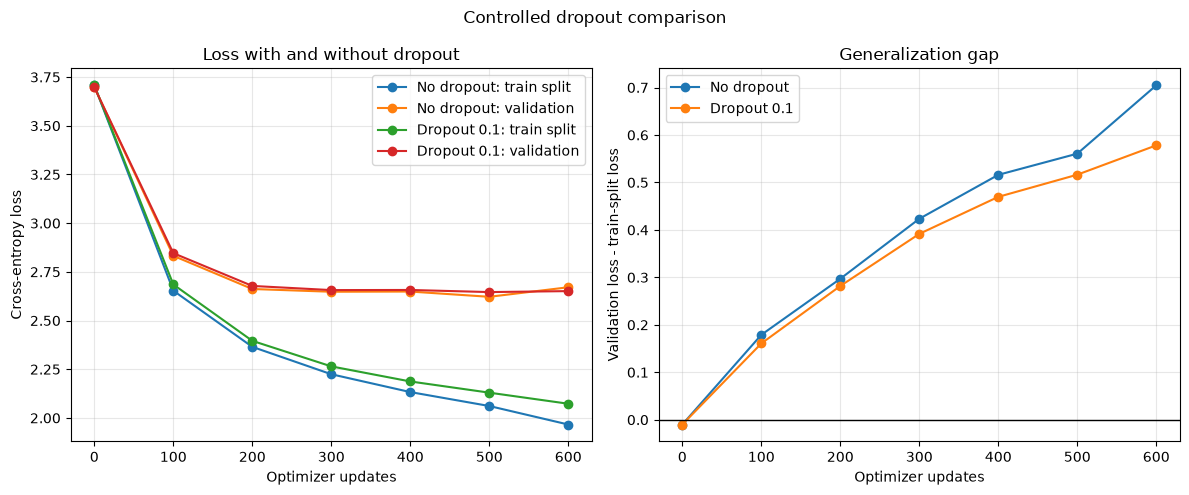

In [15]:
import matplotlib.pyplot as plt  # noqa: I001


no_dropout_gaps = [
    validation_loss - training_loss
    for training_loss, validation_loss in zip(
        no_dropout_result.training_losses,
        no_dropout_result.validation_losses,
        strict=True,
    )
]
with_dropout_gaps = [
    validation_loss - training_loss
    for training_loss, validation_loss in zip(
        with_dropout_result.training_losses,
        with_dropout_result.validation_losses,
        strict=True,
    )
]

figure, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(
    no_dropout_result.evaluation_steps,
    no_dropout_result.training_losses,
    marker="o",
    label="No dropout: train split",
)
axes[0].plot(
    no_dropout_result.evaluation_steps,
    no_dropout_result.validation_losses,
    marker="o",
    label="No dropout: validation",
)
axes[0].plot(
    with_dropout_result.evaluation_steps,
    with_dropout_result.training_losses,
    marker="o",
    label="Dropout 0.1: train split",
)
axes[0].plot(
    with_dropout_result.evaluation_steps,
    with_dropout_result.validation_losses,
    marker="o",
    label="Dropout 0.1: validation",
)
axes[0].set_xlabel("Optimizer updates")
axes[0].set_ylabel("Cross-entropy loss")
axes[0].set_title("Loss with and without dropout")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(
    no_dropout_result.evaluation_steps,
    no_dropout_gaps,
    marker="o",
    label="No dropout",
)
axes[1].plot(
    with_dropout_result.evaluation_steps,
    with_dropout_gaps,
    marker="o",
    label="Dropout 0.1",
)
axes[1].axhline(0.0, color="black", linewidth=1)
axes[1].set_xlabel("Optimizer updates")
axes[1].set_ylabel("Validation loss - train-split loss")
axes[1].set_title("Generalization gap")
axes[1].legend()
axes[1].grid(alpha=0.3)

figure.suptitle("Controlled dropout comparison")
figure.tight_layout()
plt.show()

Dropout often slows fitting of the training split because every update sees a randomly thinned network.

Whether it improves held-out loss in only 600 updates is an empirical result, not a guarantee.

## Isolate evaluation inconsistency on one fixed batch

Random validation batches can change a loss even in evaluation mode, so this test reuses one fixed batch and changes only the dropout mask seed.

In [16]:
fixed_batch_generator = torch.Generator().manual_seed(8310)
fixed_validation_inputs, fixed_validation_targets = get_gpt_training_batch(
    validation_token_ids,
    batch_size=dropout_comparison_config["batch_size"],
    context_length=dropout_comparison_config["context_length"],
    generator=fixed_batch_generator,
)


@torch.no_grad()
def compute_fixed_batch_loss(
    model: TinyGPT,
    input_batch: torch.Tensor,
    target_batch: torch.Tensor,
    use_evaluation_mode: bool,
    dropout_seed: int,
) -> float:
    if use_evaluation_mode:
        model.eval()
    else:
        model.train()
    torch.manual_seed(dropout_seed)
    _, loss = model(input_batch, target_batch)
    if loss is None:
        raise RuntimeError("Fixed-batch loss is missing.")
    return float(loss.item())


first_training_mode_loss = compute_fixed_batch_loss(
    with_dropout_result.model,
    fixed_validation_inputs,
    fixed_validation_targets,
    use_evaluation_mode=False,
    dropout_seed=1,
)
second_training_mode_loss = compute_fixed_batch_loss(
    with_dropout_result.model,
    fixed_validation_inputs,
    fixed_validation_targets,
    use_evaluation_mode=False,
    dropout_seed=2,
)
first_evaluation_mode_loss = compute_fixed_batch_loss(
    with_dropout_result.model,
    fixed_validation_inputs,
    fixed_validation_targets,
    use_evaluation_mode=True,
    dropout_seed=1,
)
second_evaluation_mode_loss = compute_fixed_batch_loss(
    with_dropout_result.model,
    fixed_validation_inputs,
    fixed_validation_targets,
    use_evaluation_mode=True,
    dropout_seed=2,
)

print("Training-mode fixed-batch losses:")
print(first_training_mode_loss, second_training_mode_loss)
print("Evaluation-mode fixed-batch losses:")
print(first_evaluation_mode_loss, second_evaluation_mode_loss)

assert first_training_mode_loss != second_training_mode_loss
assert first_evaluation_mode_loss == second_evaluation_mode_loss

Training-mode fixed-batch losses:
2.7470149993896484 2.7265067100524902
Evaluation-mode fixed-batch losses:
2.739231586456299 2.739231586456299


The different training-mode values are caused by dropout because the model parameters and batch are unchanged.

The evaluation-mode values match exactly because dropout is inactive.

## Generate with dropout disabled

Sampling already supplies randomness, so dropout should not add another changing network during generation.

The helper temporarily selects evaluation mode and then restores the model's previous mode.

In [17]:
@torch.no_grad()
def generate_character_text(
    model: TinyGPT,
    prompt: str,
    number_of_new_tokens: int,
    sampling_seed: int,
    temperature: float = 1.0,
    top_k: int | None = 10,
) -> str:
    was_training = model.training
    model.eval()
    prompt_ids = encode_text(prompt)
    sampling_generator = torch.Generator().manual_seed(sampling_seed)
    generated_ids = model.generate(
        torch.tensor([prompt_ids], dtype=torch.long),
        number_of_new_tokens=number_of_new_tokens,
        generator=sampling_generator,
        temperature=temperature,
        top_k=top_k,
    )
    model.train(was_training)
    return decode_token_ids(generated_ids[0].tolist())


with_dropout_result.model.train()
generated_sample = generate_character_text(
    with_dropout_result.model,
    prompt="Alice",
    number_of_new_tokens=180,
    sampling_seed=8311,
)

print(generated_sample)
print("Mode restored to training:", with_dropout_result.model.training)

assert with_dropout_result.model.training

Alicer wheathe tof okatery t, her.e d ick,
s was ouply t tut, whee wankalearant, thand tor s bing an t ad re plle of ish, p pe bby wit, bbl
bedas abinoonof ber and, an and ionk addery t
Mode restored to training: True


The sample is expected to be rough because the corpus and model are tiny.

Its purpose is to verify correct mode control, not to prove that dropout improves prose.

## Show the generation gotcha with greedy decoding

Top-k `1` makes token choice greedy, which removes sampling variation and leaves active dropout as the changing source.

In [18]:
@torch.no_grad()
def generate_greedy_in_selected_mode(
    model: TinyGPT,
    prompt: str,
    number_of_new_tokens: int,
    use_evaluation_mode: bool,
    dropout_seed: int,
) -> str:
    if use_evaluation_mode:
        model.eval()
    else:
        model.train()
    torch.manual_seed(dropout_seed)
    generated_ids = model.generate(
        torch.tensor([encode_text(prompt)], dtype=torch.long),
        number_of_new_tokens=number_of_new_tokens,
        generator=torch.Generator().manual_seed(1),
        top_k=1,
    )
    return decode_token_ids(generated_ids[0].tolist())


first_eval_generation = generate_greedy_in_selected_mode(
    with_dropout_result.model,
    prompt="Alice",
    number_of_new_tokens=80,
    use_evaluation_mode=True,
    dropout_seed=1,
)
second_eval_generation = generate_greedy_in_selected_mode(
    with_dropout_result.model,
    prompt="Alice",
    number_of_new_tokens=80,
    use_evaluation_mode=True,
    dropout_seed=2,
)
first_train_generation = generate_greedy_in_selected_mode(
    with_dropout_result.model,
    prompt="Alice",
    number_of_new_tokens=80,
    use_evaluation_mode=False,
    dropout_seed=1,
)
second_train_generation = generate_greedy_in_selected_mode(
    with_dropout_result.model,
    prompt="Alice",
    number_of_new_tokens=80,
    use_evaluation_mode=False,
    dropout_seed=2,
)

print(
    "Evaluation-mode greedy outputs equal:",
    first_eval_generation == second_eval_generation,
)
print(
    "Training-mode greedy outputs equal:",
    first_train_generation == second_train_generation,
)
print("Evaluation-mode output:")
print(first_eval_generation)

assert first_eval_generation == second_eval_generation

Evaluation-mode greedy outputs equal: True
Training-mode greedy outputs equal: False
Evaluation-mode output:
Alice ong the the of athe o the o o the the o o wang o the of the ther ther ther ther


Evaluation-mode greedy output is reproducible across dropout seeds.

Training-mode output can change because a new activation mask is sampled at every forward pass, even though token selection itself is greedy.

## Summarize the measured comparison

Absolute validation loss and the train-validation gap answer different questions, so both are reported.

In [19]:
print(
    "setting     | final train loss | final validation | final gap | "
    "best validation (step)"
)
print("-" * 94)
for name, result, gaps in [
    ("no dropout", no_dropout_result, no_dropout_gaps),
    ("dropout 0.1", with_dropout_result, with_dropout_gaps),
]:
    best_index = min(
        range(len(result.validation_losses)),
        key=result.validation_losses.__getitem__,
    )
    print(
        f"{name:<11} | {result.training_losses[-1]:>16.4f} | "
        f"{result.validation_losses[-1]:>16.4f} | {gaps[-1]:>9.4f} | "
        f"{result.validation_losses[best_index]:.4f} "
        f"({result.evaluation_steps[best_index]})"
    )

setting     | final train loss | final validation | final gap | best validation (step)
----------------------------------------------------------------------------------------------
no dropout  |           1.9662 |           2.6709 |    0.7047 | 2.6220 (500)
dropout 0.1 |           2.0730 |           2.6512 |    0.5782 | 2.6462 (500)


At step 600, dropout has the higher train-split loss, the smaller gap, and the slightly lower validation loss in this run.

However, the no-dropout model reached the lower best validation checkpoint at step 500, so this experiment does not establish that dropout produced the best held-out model.

A smaller gap does not help if both losses are poor, and a lower training loss can accompany worse held-out behavior.

Dropout is useful only when the full validation result supports it for the chosen model, data, and training budget.

## Choosing a dropout rate

Rates such as `0.0`, `0.1`, and `0.2` are common experiment values, not universal rules.

Dropout may help when a model has enough capacity to memorize a small dataset and a widening validation gap indicates overfitting.

Dropout may hurt when the model is already underfitting, training is too short, or the dropout rate removes too much useful signal.

The rate should be selected with held-out evaluation rather than training loss alone.

## Verify the final contracts

These assertions collect mode, rate, update-count, checkpoint, and finite-loss requirements.

In [20]:
no_dropout_layers = [
    module
    for module in no_dropout_result.model.modules()
    if isinstance(module, torch.nn.Dropout)
]
with_dropout_layers = [
    module
    for module in with_dropout_result.model.modules()
    if isinstance(module, torch.nn.Dropout)
]
expected_steps = list(range(0, 601, 100))

assert all(layer.p == 0.0 for layer in no_dropout_layers)
assert all(layer.p == 0.1 for layer in with_dropout_layers)
assert no_dropout_result.evaluation_steps == expected_steps
assert with_dropout_result.evaluation_steps == expected_steps
assert all(math.isfinite(loss) for loss in no_dropout_result.training_losses)
assert all(math.isfinite(loss) for loss in no_dropout_result.validation_losses)
assert all(math.isfinite(loss) for loss in with_dropout_result.training_losses)
assert all(math.isfinite(loss) for loss in with_dropout_result.validation_losses)

with_dropout_result.model.eval()
assert not with_dropout_result.model.training
assert not any(layer.training for layer in with_dropout_layers)

print("Dropout rates: passed")
print("Exact 600-update histories: passed")
print("Finite checkpoint losses: passed")
print("Recursive evaluation mode: passed")
print("Held-out round trip: passed")

Dropout rates: passed
Exact 600-update histories: passed
Finite checkpoint losses: passed
Recursive evaluation mode: passed
Held-out round trip: passed


## Common mistakes

- Calling `torch.no_grad()` without `model.eval()` leaves dropout active.

- Calling `model.eval()` without `torch.no_grad()` still builds gradient graphs unless another context disables them.

- Sampling random validation batches twice can mimic inconsistency even when dropout is off.

- Applying dropout directly to integer token IDs is invalid because dropout operates on floating-point activations.

- Dropping the combined residual stream changes the identity path instead of regularizing only the transformed branch.

- Comparing stochastic update loss with deterministic evaluation loss without labeling their modes is misleading.

- Taking one update after the final checkpoint silently turns a 600-step run into 601 updates.

- Assuming dropout must improve validation loss ignores underfitting, training duration, and dataset size.

## Takeaways

- Training-mode dropout zeros activations and scales survivors so each fixed activation is unchanged in expectation.

- Evaluation-mode dropout is the identity function.

- TinyGPT applies dropout to embeddings, attention weights, attention branch outputs, and feedforward branch outputs.

- The undropped residual stream remains available around each transformed branch.

- `model.eval()` and `torch.no_grad()` solve different parts of correct evaluation.

- A controlled comparison needs identical initialization, batches, held-out examples, and optimizer-update counts.

- Dropout can reduce overfitting, but held-out loss determines whether it helped in a particular run.

- Generation should disable dropout so sampling is the deliberate source of randomness.

## What comes next

Dropout addresses activation-level regularization, while later chapters can address optimization controls such as gradient clipping and learning-rate schedules.

Those tools solve different failure modes and should be evaluated with the same held-out discipline.